In [188]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']   # 指定一个系统中一定存在的英文字体
plt.rcParams['font.family'] = 'sans-serif'          # 使用 sans-serif 字体系列

In [189]:
# 线性回归类主体
class LinearRegressionScratch:
    def __init__(self) :
        self.B0 = None # 不带截矩
        self.B1 = None # 带截矩

    # 线性回归求解
    def regress(self ,X , Y) :
        # 正规方程求解
        self.B0 = np.linalg.inv(X.T @ X) @ (X.T @ Y)

        X1 = np.column_stack([np.ones(len(X)) , X])
        self.B1 = np.linalg.inv(X1.T @ X1) @ (X1.T @ Y)

    # 使用得到的模型进行预测
    def predict(self , X ,flag=True) :
        # 使用截矩
        if flag :
            X = np.column_stack([np.ones(len(X)) , X])
            res = X @ self.B1
        # 不使用截矩
        else :
            res = X @ self.B0
            
        return res

    # 评估线性回归的函数。返回残差平方和Q2 与 决定系数R2
    def evaluate(self , X , Y , flag=True) :
        Y_hat = self.predict(X , flag)
        Q = Y - Y_hat # 残差
        Q2 = np.sum(Q ** 2)  # 残差平方和
        R2 = 1 - Q2 / np.sum((Y - np.mean(Y)) ** 2) # 决定系数
        return Q2 , R2

In [190]:
# 数据加载
housing = datasets.fetch_california_housing()
X = housing.data  # 特征矩阵X
Y = housing.target  # 结果向量Y
feature_names = housing.feature_names

# 将数据集划分为 80%训练集 20%测试集
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# 基于训练集计算均值和标准差（样本标准差，ddof=1）
train_mean = np.mean(X_train, axis=0)
train_std  = np.std(X_train, axis=0, ddof=1)
train_std[train_std == 0] = 1.0      # 避免常数特征导致除零

# 将训练集和测试集都按训练集的参数进行标准化
#X_train = (X_train - train_mean) / train_std
#X_test  = (X_test  - train_mean) / train_std

In [191]:
model = LinearRegressionScratch()

model.regress(X_train , Y_train)


Q2 , R2  = model.evaluate(X_train , Y_train)
print(f"训练集(带截矩)   - 残差平方和: {Q2:.2f}, 决定系数: {R2:.4f}")
Q2 , R2 = model.evaluate(X_train , Y_train , False)
print(f"训练集(不带截矩) - 残差平方和: {Q2:.2f}, 决定系数: {R2:.4f}")
Q2 , R2 = model.evaluate(X_test , Y_test)
print(f"测试集(带截矩)   - 残差平方和: {Q2:.2f}, 决定系数: {R2:.4f}")
Q2 , R2 = model.evaluate(X_test , Y_test , False)
print(f"测试集(不带截矩) - 残差平方和: {Q2:.2f}, 决定系数: {R2:.4f}")

训练集(带截矩)   - 残差平方和: 8552.11, 决定系数: 0.6126
训练集(不带截矩) - 残差平方和: 9891.28, 决定系数: 0.5519
测试集(带截矩)   - 残差平方和: 2294.72, 决定系数: 0.5758
测试集(不带截矩) - 残差平方和: 2598.36, 决定系数: 0.5197


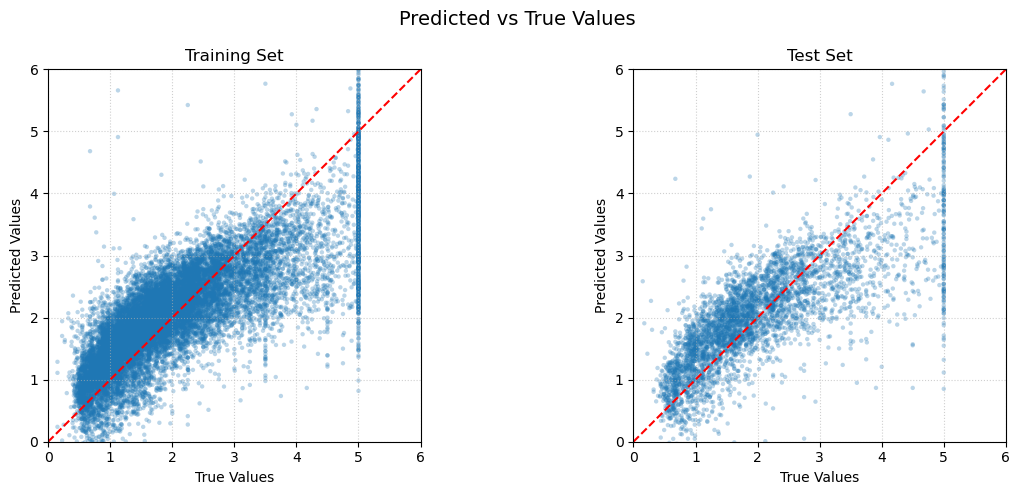

In [192]:
# 可视化部分
'''
图1 真实值与预测值对比图
横纵坐标分别为预测值与真实值。拟合效果越好，则散点图应趋向一条直线
'''
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12

y_train_pred = model.predict(X_train, flag=True)
y_test_pred = model.predict(X_test, flag=True)

# 计算统一的坐标轴范围，保证两图跨度一致

all_true = np.concatenate([Y_train, Y_test])
all_pred = np.concatenate([y_train_pred, y_test_pred])
global_min = min(all_true.min(), all_pred.min())
global_max = max(all_true.max(), all_pred.max())
# 稍微扩展一点范围，让点不贴在边框上
margin = 0.05 * (global_max - global_min)
axis_lim = [global_min - margin, global_max + margin]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 训练集
axes[0].scatter(Y_train, y_train_pred, alpha=0.3, edgecolor='none', s=10)
axes[0].plot([0, 6], [0, 6], 'r--', linewidth=1.5)   # y=x 参考线，范围固定为[0,7]
axes[0].set_xlim(0, 6)
axes[0].set_ylim(0, 6)
axes[0].set_xlabel('True Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Training Set')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].set_aspect('equal', adjustable='box')

# 测试集
axes[1].scatter(Y_test, y_test_pred, alpha=0.3, edgecolor='none', s=10)
axes[1].plot([0, 6], [0, 6], 'r--', linewidth=1.5)
axes[1].set_xlim(0, 6)
axes[1].set_ylim(0, 6)
axes[1].set_xlabel('True Values')
axes[1].set_ylabel('Predicted Values')
axes[1].set_title('Test Set')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].set_aspect('equal', adjustable='box')

fig.suptitle('Predicted vs True Values', fontsize=14)
plt.tight_layout()
plt.show()




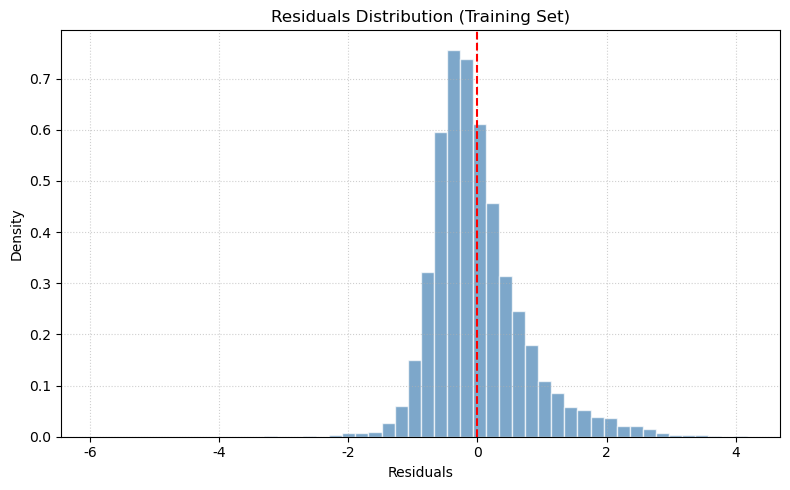

In [193]:
'''
图2. 残差分布直方图
图中可看出，对于绝大部分样本，其计算出的残差都在较小范围内
'''
residuals_train = Y_train - y_train_pred
plt.figure(figsize=(8, 5))
plt.hist(residuals_train, bins=50, density=True, alpha=0.7, color='steelblue',
         edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Residuals Distribution (Training Set)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()